In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

import nltk
nltk.download('punkt')
print("Libraries Imported Successfully!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\x390\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


Libraries Imported Successfully!


Explanation

This code imports the Python libraries required for the project. Pandas is used for data manipulation, NumPy for numerical operations, Matplotlib and Seaborn for data visualization, TextBlob for sentiment analysis, and WordCloud for visualizing frequently used words in customer reviews

In [ ]:
df = pd.read_csv("Amazon Alexa Reviews.csv")

This code loads the Amazon Reviews dataset into a Pandas DataFrame named df, allowing us to analyze customer review data.

Display First 5 Rows

In [26]:
df.head()

,Rating,Date,Variation,Verified_Reviews,Feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


Explanation

The head() function displays the first five rows of the dataset. This helps verify that the dataset has been loaded correctly and provides an overview of its structure.

Explore Dataset

Dataset Shape

In [27]:
print("Rows and Columns:", df.shape)

Rows and Columns: (3150, 5)


Column Names

In [28]:
print(df.columns)

Index(['Rating', 'Date', 'Variation', 'Verified_Reviews', 'Feedback'], dtype='str')


Dataset Information

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Rating            3150 non-null   int64
 1   Date              3150 non-null   str  
 2   Variation         3150 non-null   str  
 3   Verified_Reviews  3149 non-null   str  
 4   Feedback          3150 non-null   int64
dtypes: int64(2), str(3)
memory usage: 123.2 KB


Missing Values

In [30]:
df.isnull().sum()

Rating              0
Date                0
Variation           0
Verified_Reviews    1
Feedback            0
dtype: int64

Clean the Data

Remove missing values:

In [31]:
df.dropna(inplace=True)

In [32]:
df.isnull().sum()

Rating              0
Date                0
Variation           0
Verified_Reviews    0
Feedback            0
dtype: int64

Basic Statistics

In [33]:
df.describe()

,Rating,Feedback
count,3149.000000,3149.000000
mean,4.463957,0.918704
std,1.067773,0.273332
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


Rating Distribution

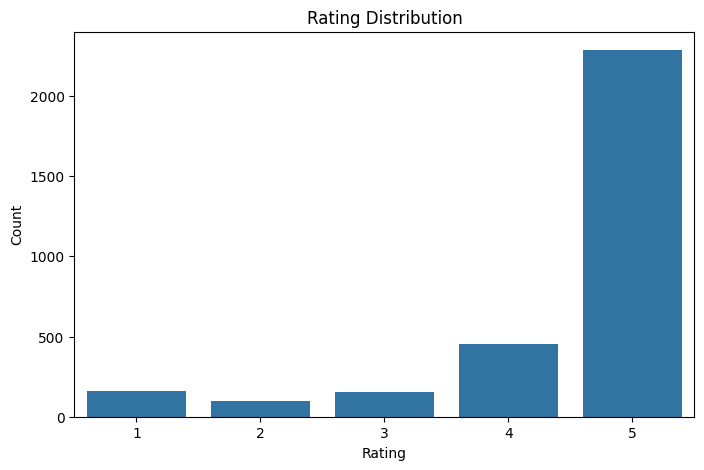

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Rating")

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

Explanation

This bar chart shows how many customers gave each rating. It helps identify the overall distribution of customer ratings and whether most customers were satisfied with the product.

Observation

Most customers gave 5-star ratings, indicating a high level of customer satisfaction

 Sentiment Function

In [38]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

Explanation

This function analyzes each customer review using TextBlob. It calculates a polarity score and classifies the review as Positive, Negative, or Neutral based on that score.

Sentiment Analysis

In [39]:
df["Sentiment"] = df["Verified_Reviews"].apply(get_sentiment)

Explanation

This code applies the sentiment analysis function to every review in the Verified_Reviews column and stores the result in a new column named Sentiment.

Show Results

In [40]:
df[["Verified_Reviews", "Sentiment"]].head(10)

,Verified_Reviews,Sentiment
0,Love my Echo!,Positive
1,Loved it!,Positive
2,"Sometimes while playing a game, you can answer...",Negative
3,I have had a lot of fun with this thing. My 4 ...,Positive
4,Music,Neutral
5,I received the echo as a gift. I needed anothe...,Positive
6,"Without having a cellphone, I cannot use many ...",Positive
7,I think this is the 5th one I've purchased. I'...,Positive
8,looks great,Positive
9,Love it! I’ve listened to songs I haven’t hear...,Positive


Explanation

This displays the first ten customer reviews along with their predicted sentiment labels, allowing us to verify that the classification is working correctly.

Sentiment Distribution

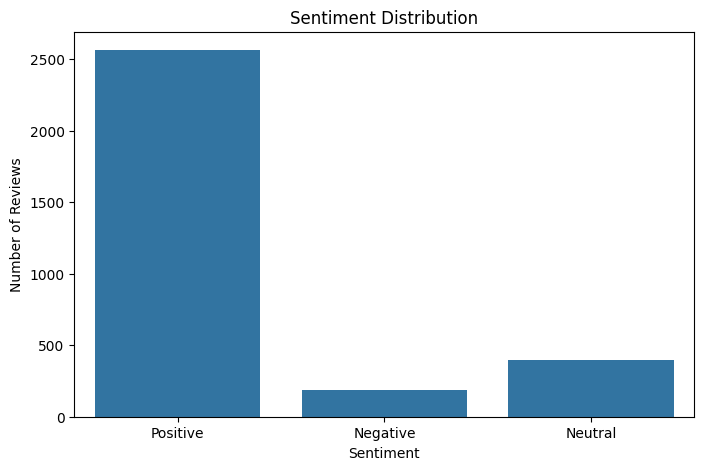

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

Explanation

This chart displays the number of Positive, Negative, and Neutral reviews. It provides a quick overview of overall customer opinion.

Observation

The majority of customer reviews are Positive, indicating that customers generally have a favorable opinion of the product.

Pie Chart

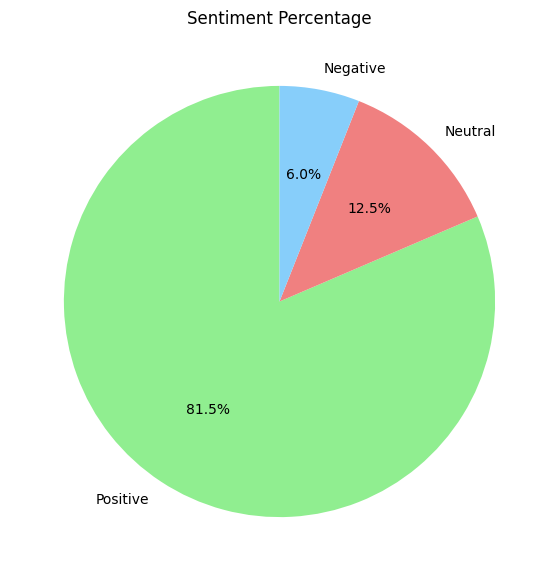

In [43]:
plt.figure(figsize=(7,7))

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["lightgreen","lightcoral","lightskyblue"]
)

plt.title("Sentiment Percentage")
plt.ylabel("")

plt.show()

Explanation

This pie chart shows the percentage distribution of Positive, Negative, and Neutral reviews, making it easy to compare the overall sentiment.

Observation

Positive reviews occupy the largest portion of the chart, showing that customer satisfaction is high.

Positive Word Cloud

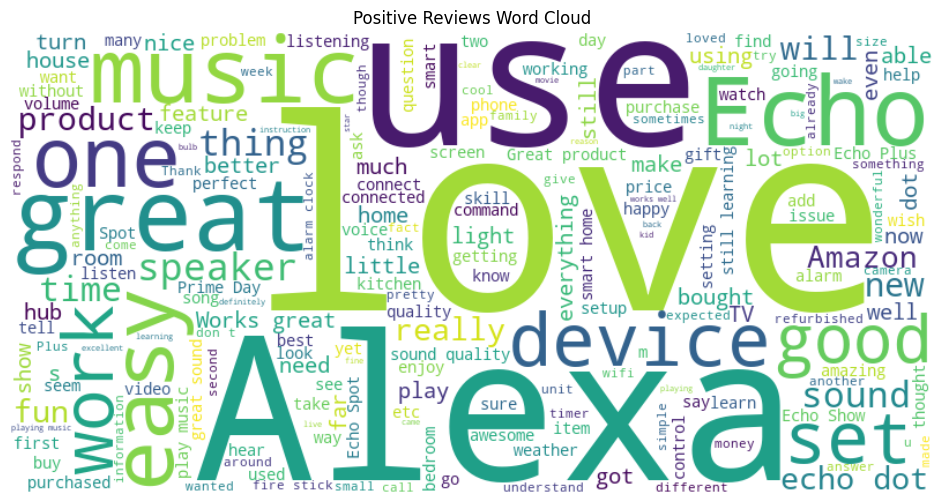

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

positive_reviews = " ".join(
    df[df["Sentiment"]=="Positive"]["Verified_Reviews"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_reviews)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Positive Reviews Word Cloud")

plt.show()

Explanation

This code creates a word cloud using only positive reviews. Frequently used words appear larger, helping identify the features customers appreciate most.

Observation

Large words represent the most frequently mentioned positive terms in customer reviews.

Negative Word Cloud

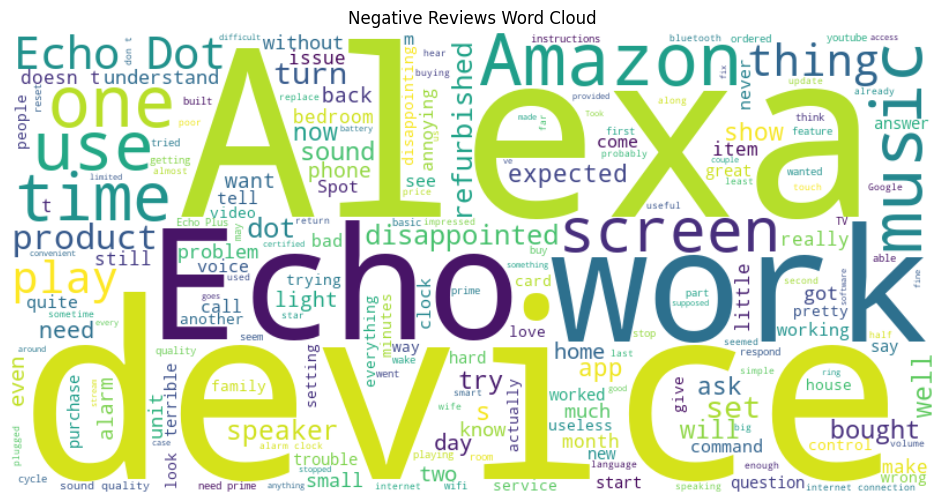

In [46]:
negative_reviews = " ".join(
    df[df["Sentiment"]=="Negative"]["Verified_Reviews"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_reviews)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Negative Reviews Word Cloud")

plt.show()

Explanation

This code generates a word cloud using negative reviews. It highlights the words most commonly associated with customer complaints.

Observation

Frequently occurring negative words help identify areas where the product can be improved.

Business Insights


1. Overall Customer Sentiment

Insight:
        Most customer reviews are Positive, indicating that customers are generally satisfied with the Amazon Alexa product.

Business Value:

            High customer satisfaction improves brand reputation.
            Positive reviews can be used in marketing campaigns.
            The company should continue maintaining product quality.

2. Customer Ratings
Insight:
        The majority of customers gave 5-star ratings.

Business Value:
             High ratings increase customer trust.
             Products with more 5-star reviews attract more buyers.


3. Negative Reviews
Insight:
        A small percentage of reviews are negative.

Business Value:
            Analyze common complaints.
            Improve product features based on customer feedback.
            Reduce customer dissatisfaction.

4. Neutral Reviews
Insight:
        Neutral reviews indicate customers who neither strongly liked nor disliked the product.

Business Value:
            These customers may become loyal if improvements are made.
            Marketing campaigns can encourage them to upgrade or purchase again.

5. Product Development

Recommendation:
The company should focus on:
                            Improving features mentioned in negative reviews.
                            Fixing connectivity or performance issues (if identified).
                            Continuously collecting customer feedback.

6. Marketing Strategy

Recommendation:
Marketing should highlight:
                            Positive customer experiences.
                            High ratings.
                            Frequently praised product features.

7. Public Opinion
Insight:
Sentiment analysis shows that public opinion is mostly positive, indicating strong acceptance of the product.

9. Conclusion

The sentiment analysis successfully classified customer reviews into positive, negative, and neutral categories using NLP techniques. The visualizations provided clear insights into customer opinions, while the business recommendations demonstrated how sentiment analysis can support marketing strategies and product improvements.